In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [6]:
df = pd.read_csv("customer_booking.csv",encoding='latin1')
df.head()


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [7]:
df.shape

(50000, 14)

In [9]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [12]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [13]:
df['booking_complete'].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [14]:
df['booking_complete'].value_counts(normalize=True)*100

booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64

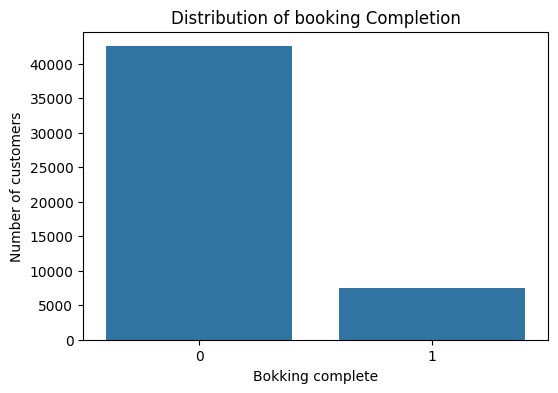

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='booking_complete')
plt.title("Distribution of booking Completion")
plt.xlabel("Bokking complete")
plt.ylabel("Number of customers")
plt.show()

In [16]:
categorical_columns = [
    "sales_channel",
    "trip_type",
    "flight_day",
    "route",
    "booking_origin"
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].nunique(), "unique values")
    print(df[column].value_counts().head(10))


 sales_channel
2 unique values
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

 trip_type
3 unique values
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

 flight_day
7 unique values
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

 route
799 unique values
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

 booking_origin
104 unique values
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64


In [17]:
numerical_columns = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration"
]

df[numerical_columns].describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_duration
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,7.277561
std,1.020165,90.451378,33.88767,5.41266,1.496863
min,1.000000,0.000000,0.00000,0.00000,4.670000
25%,1.000000,21.000000,5.00000,5.00000,5.620000
50%,1.000000,51.000000,17.00000,9.00000,7.570000
75%,2.000000,115.000000,28.00000,13.00000,8.830000
max,9.000000,867.000000,778.00000,23.00000,9.500000


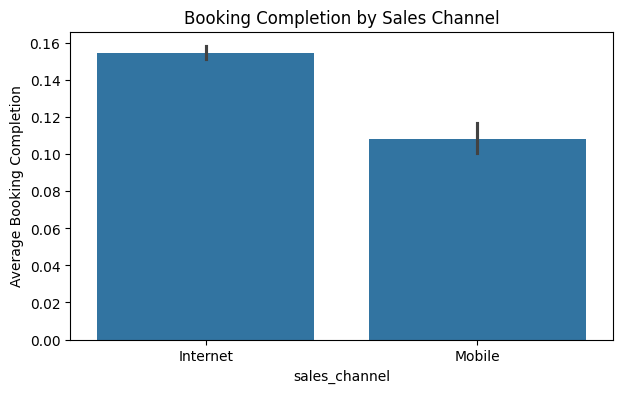

In [19]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df,x="sales_channel",y="booking_complete")
plt.title("Booking Completion by Sales Channel")
plt.ylabel("Average Booking Completion")
plt.show()

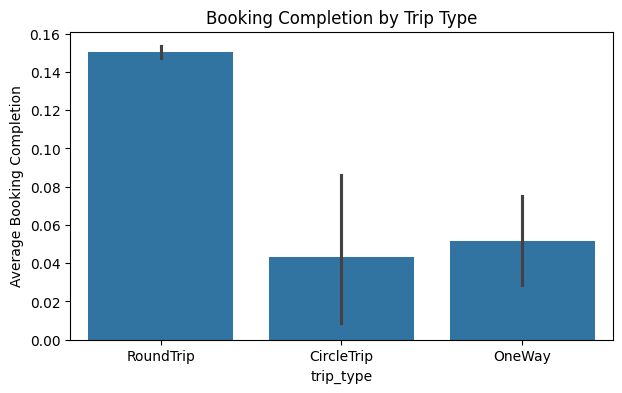

In [20]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df,x="trip_type",y="booking_complete")
plt.title("Booking Completion by Trip Type")
plt.ylabel("Average Booking Completion")
plt.show()

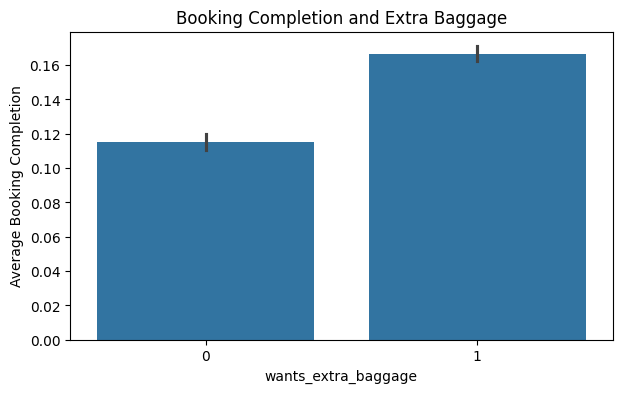

In [21]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df,x="wants_extra_baggage",y="booking_complete")
plt.title("Booking Completion and Extra Baggage")
plt.ylabel("Average Booking Completion")
plt.show()

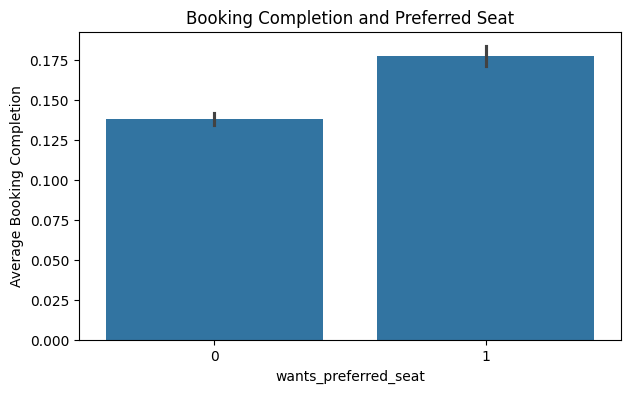

In [22]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df,x="wants_preferred_seat",y="booking_complete")
plt.title("Booking Completion and Preferred Seat")
plt.ylabel("Average Booking Completion")
plt.show()

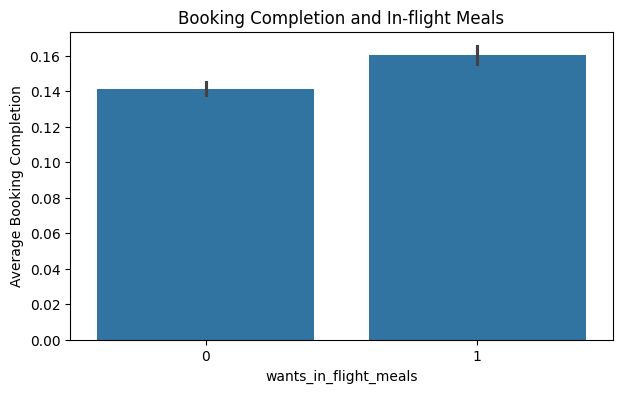

In [23]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df,x="wants_in_flight_meals",y="booking_complete")
plt.title("Booking Completion and In-flight Meals")
plt.ylabel("Average Booking Completion")
plt.show()

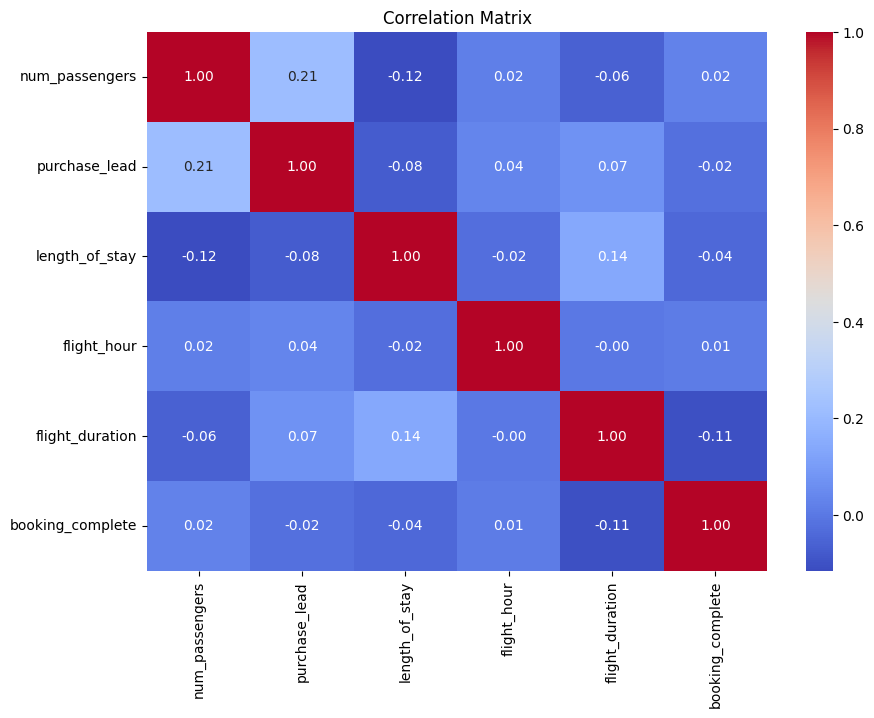

In [24]:
plt.figure(figsize=(10, 7))
correlation = df[numerical_columns + ["booking_complete"]].corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [25]:
def classify_flight_hour(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"
df["flight_period"] = df["flight_hour"].apply(classify_flight_hour)

In [26]:
df["flight_period"].value_counts()

flight_period
Morning      18668
Night        14619
Afternoon    13749
Evening       2964
Name: count, dtype: int64

In [27]:
def classify_purchase_lead(days):
    if days <= 7:
        return "0-7 days"
    elif days <= 30:
        return "8-30 days"
    elif days <= 90:
        return "31-90 days"
    else:
        return "90+ days"
df["purchase_lead_category"] = df["purchase_lead"].apply(classify_purchase_lead)

In [28]:
df['purchase_lead_category'].value_counts()

purchase_lead_category
31-90 days    17015
90+ days      15846
8-30 days     12326
0-7 days       4813
Name: count, dtype: int64

In [29]:
def classify_stay(days):
    if days <= 3:
        return "Short"
    elif days <= 7:
        return "Medium"
    else:
        return "Long"
df["stay_category"] = df["length_of_stay"].apply(classify_stay)

In [30]:
df['stay_category'].value_counts()

stay_category
Long      25327
Medium    20698
Short      3975
Name: count, dtype: int64

In [33]:
X=df.drop('booking_complete',axis=1)
y=df['booking_complete']

X.shape
y.shape

(50000,)

In [34]:
categorical_features = [
    "sales_channel",
    "trip_type",
    "flight_day",
    "route",
    "booking_origin",
    "flight_period",
    "purchase_lead_category",
    "stay_category"
]

In [35]:
numerical_features = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_duration",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals"
]

In [37]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print('training set:',X_train.shape)
print('testing set:',X_test.shape)

training set: (40000, 16)
testing set: (10000, 16)


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

model = RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1,class_weight="balanced")
pipeline = Pipeline(steps=[('preprocessor',preprocessor),('model',model)])
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sales_channel', 'trip_type',
                                                   'flight_day', 'route',
                                                   'booking_origin',
                                                   'flight_period',
                                                   'purchase_lead_category',
                                                   'stay_category']),
                                                 ('numerical', 'passthrough',
                                                  ['num_passengers',
                                                   'purchase_lead',
                                                   'length_of_stay',
                                                   'flight_hour',
                                                   'flight_duration',
                                                   'wants_extra_baggage',
                                                   'wants_preferred_seat',
                                                   'wants_in_flight_meals'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [46]:
y_pred =pipeline.predict(X_test)
y_probability = pipeline.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)

precision = precision_score(y_test,y_pred)
print('Precision:',precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test,y_pred)
print('F1 score:',f1)

roc_auc = roc_auc_score(y_test,y_probability)
print("ROC-AUC:",roc_auc)

accuracy: 0.8527
Precision: 0.5454545454545454
Recall: 0.09224598930481283
F1 score: 0.15780445969125215
ROC-AUC: 0.7904061976496747


In [48]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.55      0.09      0.16      1496

    accuracy                           0.85     10000
   macro avg       0.70      0.54      0.54     10000
weighted avg       0.81      0.85      0.81     10000



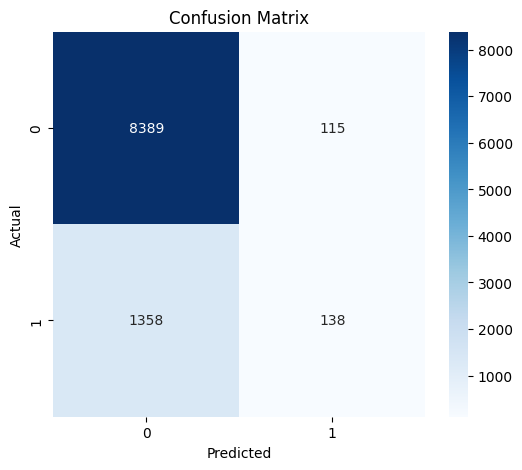

In [49]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

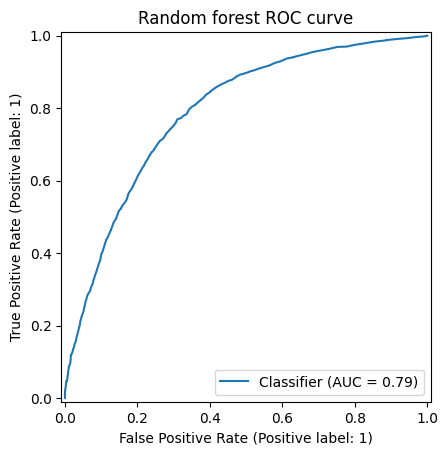

In [50]:
RocCurveDisplay.from_predictions(y_test,y_probability)
plt.title('Random forest ROC curve')
plt.show()

In [52]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_results= cross_validate(pipeline,X,y,cv=cv,scoring=['accuracy','precision','recall','f1','roc_auc'],n_jobs=-1)

In [53]:
print("Mean Accuracy:",cv_results["test_accuracy"].mean())
print("Mean Precision:",cv_results["test_precision"].mean())
print("Mean Recall:",cv_results["test_recall"].mean())
print("Mean F1:",cv_results["test_f1"].mean())
print("Mean ROC-AUC:",cv_results["test_roc_auc"].mean())

Mean Accuracy: 0.8533199999999999
Mean Precision: 0.5512000172050144
Mean Recall: 0.10269990878686533
Mean F1: 0.17304627574075396
Mean ROC-AUC: 0.7845648741126175


In [54]:
print("Accuracy ± SD:",
    f"{cv_results['test_accuracy'].mean():.4f} "
    f"± {cv_results['test_accuracy'].std():.4f}")

print("ROC-AUC ± SD:",
    f"{cv_results['test_roc_auc'].mean():.4f} "
    f"± {cv_results['test_roc_auc'].std():.4f}")

Accuracy ± SD: 0.8533 ± 0.0010
ROC-AUC ± SD: 0.7846 ± 0.0018


In [56]:
rf_model = pipeline.named_steps['model']
preprocessor_fitted = pipeline.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importance})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(20)

,Feature,Importance
920,numerical__purchase_lead,0.092824
921,numerical__length_of_stay,0.072855
922,numerical__flight_hour,0.071051
923,numerical__flight_duration,0.045730
810,categorical__booking_origin_Australia,0.045025
919,numerical__num_passengers,0.034415
856,categorical__booking_origin_Malaysia,0.033717
926,numerical__wants_in_flight_meals,0.020162
924,numerical__wants_extra_baggage,0.017790
925,numerical__wants_preferred_seat,0.016497


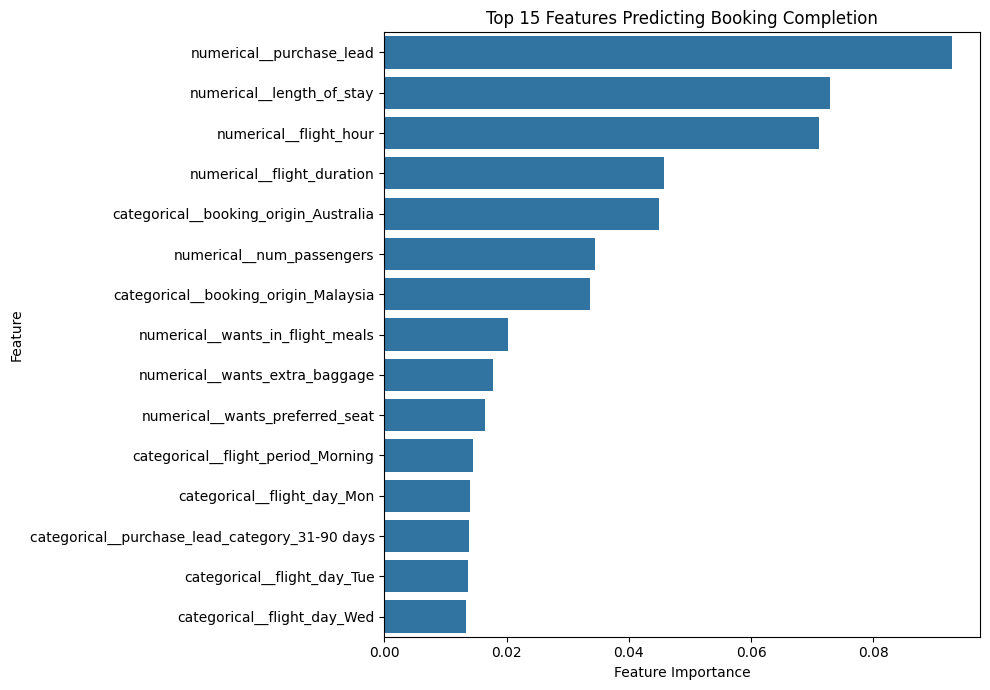

In [59]:
top_features = feature_importance.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(data=top_features,x="Importance",y="Feature")
plt.title("Top 15 Features Predicting Booking Completion")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [62]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)
feature_importance.head(15)

,Feature,Importance
920,purchase_lead,0.092824
921,length_of_stay,0.072855
922,flight_hour,0.071051
923,flight_duration,0.045730
810,booking_origin_Australia,0.045025
919,num_passengers,0.034415
856,booking_origin_Malaysia,0.033717
926,wants_in_flight_meals,0.020162
924,wants_extra_baggage,0.017790
925,wants_preferred_seat,0.016497


In [64]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Metric,Score
0,Accuracy,0.852700
1,Precision,0.545455
2,Recall,0.092246
3,F1 Score,0.157804
4,ROC-AUC,0.790406


In [66]:
metrics.to_csv(
    "model_metrics.csv",
    index=False
)

feature_importance.head(15)

,Feature,Importance
920,purchase_lead,0.092824
921,length_of_stay,0.072855
922,flight_hour,0.071051
923,flight_duration,0.045730
810,booking_origin_Australia,0.045025
919,num_passengers,0.034415
856,booking_origin_Malaysia,0.033717
926,wants_in_flight_meals,0.020162
924,wants_extra_baggage,0.017790
925,wants_preferred_seat,0.016497
